# Hyperparameter Sweep — Latent JacobianODE

This notebook launches a hyperparameter sweep for the **Latent JacobianODE** model.
It supports two training modes:

- **`from_scratch`**: Encoder and JacobianODE are trained jointly from random initialization.
- **`pretrained`**: A pre-trained encoder (loaded from W&B) is used; only the JacobianODE is trained (encoder optionally fine-tuned).

**Supports two data sources** (set `DATA_SOURCE` in Section 1 for from_scratch; inherited from encoder for pretrained):
- `"dysts"` — synthetic trajectories from dynamical systems (e.g. Lorenz)
- `"wmtask"` — hidden-state trajectories from a trained working memory RNN

**Workflow:**
1. Select the training mode and configure hyperparameters (Sections 1–3)
2. Build the Hydra config and generate data (Sections 4–5)
3. Launch the Hydra `--multirun` sweep via SLURM (Section 6)
4. After training completes, use the companion **Sweep Analytics** notebook for model selection and diagnostics.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import subprocess
import torch
from tqdm.auto import tqdm
import wandb

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
)
from JacobianODE.jacobians.tuning import DEFAULT_LAMBDA_LOOP_VALUES

torch.set_float32_matmul_precision('high')

## 1. Training Mode and Data Source

Set `MODE` to `"from_scratch"` or `"pretrained"`.

- **`from_scratch`**: Define encoder architecture below (Section 2a). Set `DATA_SOURCE` to `"dysts"` or `"wmtask"` in the Paths cell.
- **`pretrained`**: Specify the W&B project and run ID of the pre-trained encoder (Section 2b). Data source is inherited from the encoder config.

In [ ]:
# ----------------------------------------------------------------
# Training mode: "from_scratch" or "pretrained"
# ----------------------------------------------------------------
MODE = "from_scratch"  # <-- CHANGE THIS

assert MODE in ("from_scratch", "pretrained"), f"Invalid MODE: {MODE}"

# ----------------------------------------------------------------
# Encoder type (only relevant for from_scratch mode):
#   "mlp"              — pointwise MLP (dimension-reducing, existing behavior)
#   "coupling"         — AffineCouplingEncoder (dimension-preserving, invertible)
#   "spline_coupling"  — CouplingEncoder with rational quadratic splines + ActNorm
# ----------------------------------------------------------------
# ENCODER_TYPE = "mlp"  # <-- CHANGE THIS
ENCODER_TYPE = "coupling"
# ENCODER_TYPE = "spline_coupling"

assert ENCODER_TYPE in ("mlp", "coupling", "spline_coupling"), f"Invalid ENCODER_TYPE: {ENCODER_TYPE}"
print(f"Training mode: {MODE}, Encoder: {ENCODER_TYPE}")

In [4]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR     = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"
WANDB_ENTITY = "JacobianODE"

# ----------------------------------------------------------------
# Data source: "dysts" or "wmtask" (from_scratch only; pretrained inherits from encoder)
# ----------------------------------------------------------------
DATA_SOURCE = "dysts"   # <-- change to "wmtask" for WM task RNN data
# DATA_SOURCE = "wmtask"

# ----------------------------------------------------------------
# wmtask-specific hyperparameters (ignored when DATA_SOURCE="dysts")
# ----------------------------------------------------------------
WMTASK_PROJECT = "WMSelectionTask__cue_time_0.1__response_time_0.25__enforce_fixation_False"
WMTASK_NAME = "BiologicalRNN__cue_time_0.1__learning_rate_0.0005__max_epochs_42__N1_64__N2_64__tau_0.05__dt_0.02__eig_lower_bound_0.1__init_mode_random"
WMTASK_MODEL_TO_LOAD = "final"
WMTASK_DATALOADER = "all"
WMTASK_TRAJ_WINDOW = "delay2"   # 'delay2' or 'full'
WMTASK_DIM = 128                # N1 + N2 = 64 + 64

os.makedirs(SAVE_DIR, exist_ok=True)
if DATA_SOURCE == "dysts":
    data_dir = f"{SAVE_DIR}/dysts_data"
    os.makedirs(data_dir, exist_ok=True)

## 2a. From-Scratch Encoder Settings

*Skip this section if `MODE = "pretrained"`.*

In [ ]:
# ================================================================
# From-scratch encoder settings (skip if MODE == "pretrained")
# ================================================================
if MODE == "from_scratch":

    if ENCODER_TYPE == "mlp":
        # --- MLP encoder (pointwise: same MLP at every timestep) ---
        MLP_HIDDEN_DIM = 256
        MLP_N_LAYERS   = 3
        MLP_DROPOUT    = 0.1

        # Decoder MLP (pointwise: z_t -> x_hat_t)
        DECODER_HIDDEN = 128
        DECODER_LAYERS = 2

        # Decode only the most recent delay (first N columns of delay embedding)?
        # When False, the decoder reconstructs the full delay embedding.
        # When True, the decoder only reconstructs the most recent delay block
        # (i.e. the raw observed dimensions, not the full n_delays * n_obs embedding).
        # DECODE_ONLY_RECENT = False
        DECODE_ONLY_RECENT = True

    elif ENCODER_TYPE == "coupling":
        # --- Affine Coupling Flow encoder (dimension-preserving, invertible) ---
        N_COUPLING_LAYERS   = 8      # number of affine coupling stacks
        COUPLING_HIDDEN_DIM = 128    # conditioner MLP width
        N_HIDDEN_LAYERS     = 2      # conditioner MLP depth
        SCALE_ACTIVATION    = "tanh" # bounds log-scale via tanh(·)
        SCALE_CLAMP         = 3.0    # max |log_s|, ~20× scaling range
        ZERO_INIT           = True   # identity initialization trick
        PERMUTATION_SEED    = 42      # base seed for fixed random permutations

        # ---- Numerical stability (Andrade 2024, arXiv:2402.16408) ----
        CLAMP_TYPE          = "symmetric"  # 'symmetric' | 'asymmetric'
        ALPHA_POS           = 0.1          # asymmetric clamp: expansion bound
        ALPHA_NEG           = 2.0          # asymmetric clamp: compression bound
        USE_LOFT            = False        # LOFT layer after coupling blocks
        LOFT_TAU            = 100.0        # LOFT threshold

        # Coupling has an exact inverse → no separate decoder needed
        DECODE_ONLY_RECENT = False

        # ---- Subspace splitting ----
        N_TARGET_DIMS       = 3          # dynamic subspace (e.g. 3 for Lorenz)
        # N_TARGET_DIMS       = 6          # dynamic subspace (e.g. 3 for Lorenz)
        ZERO_PENALTY_WEIGHT = 1.0        # MSE penalty for z_null → 0
        # ZERO_PENALTY_WEIGHT = 0.0
        RECONSTRUCTION_MODE = "most_recent"  # 'uniform' | 'harmonic' | 'most_recent'

        # ---- Tangent space entropy regularizer ----
        TANGENT_ENTROPY_WEIGHT    = 0.0
        # TANGENT_ENTROPY_WEIGHT    = None # sweep it
        TANGENT_ENTROPY_MODE      = "quadratic"  # 'shannon' | 'quadratic' | 'renyi_half'
        TANGENT_ENTROPY_N_SAMPLES = 256

    elif ENCODER_TYPE == "spline_coupling":
        # --- Spline Coupling Flow encoder (rational quadratic splines + ActNorm) ---
        N_COUPLING_LAYERS   = 8      # number of spline coupling stacks
        COUPLING_HIDDEN_DIM = 128    # conditioner MLP width
        N_HIDDEN_LAYERS     = 2      # conditioner MLP depth
        NUM_BINS            = 8      # rational quadratic spline segments
        TAIL_BOUND          = 3.0    # linear tails outside [-B, B]
        USE_ACTNORM         = True   # ActNorm between coupling layers
        ZERO_INIT           = True   # identity initialization trick
        PERMUTATION_SEED    = 42     # base seed for fixed random permutations
        USE_LOFT            = False  # LOFT layer after coupling blocks
        LOFT_TAU            = 100.0  # LOFT threshold

        # Coupling has an exact inverse → no separate decoder needed
        DECODE_ONLY_RECENT = False

        # ---- Subspace splitting ----
        N_TARGET_DIMS       = 3          # dynamic subspace (e.g. 3 for Lorenz)
        ZERO_PENALTY_WEIGHT = 1.0        # MSE penalty for z_null → 0
        RECONSTRUCTION_MODE = "most_recent"  # 'uniform' | 'harmonic' | 'most_recent'

        # ---- Tangent space entropy regularizer ----
        TANGENT_ENTROPY_WEIGHT    = 0.0
        TANGENT_ENTROPY_MODE      = "quadratic"  # 'shannon' | 'quadratic' | 'renyi_half'
        TANGENT_ENTROPY_N_SAMPLES = 256

    ENCODER_WARMUP_EPOCHS = 5

## 2b. Pre-trained Encoder Settings

*Skip this section if `MODE = "from_scratch"`.*

In [6]:
# ================================================================
# Pre-trained encoder settings (skip if MODE == "from_scratch")
# ================================================================
if MODE == "pretrained":
    from JacobianODE.encoder_only.pretrained import load_pretrained_encoder

    ENCODER_SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/encoder_runs"

    # Encoder source on W&B
    ENCODER_PROJECT = "Lorenz_MLPFULL_Normed_L6__EncoderOnly"
    ENCODER_RUN_ID  = "vc98usdl"

    FREEZE_ENCODER = False

    adapter, encoder_cfg, encoder_run = load_pretrained_encoder(
        project=ENCODER_PROJECT,
        run_id=ENCODER_RUN_ID,
        save_dir=ENCODER_SAVE_DIR,
        freeze=FREEZE_ENCODER,
        verbose=True,
    )

    print(f"Encoder type:    {type(adapter.encoder).__name__}")
    print(f"n_latent:        {adapter.n_latent}")
    print(f"context_margin:  {adapter.context_margin}")
    print(f"Frozen:          {FREEZE_ENCODER}")

## 3. Hyperparameters

In [7]:
# ----------------------------------------------------------------
# Data hyperparameters
# ----------------------------------------------------------------
if MODE == "pretrained":
    # Infer DATA_SOURCE from encoder config; inherit all data settings
    _enc_data_type = getattr(encoder_cfg.data, "data_type", "dysts")
    DATA_SOURCE = str(_enc_data_type) if _enc_data_type in ("dysts", "wmtask") else "dysts"

    OBS_NOISE     = float(encoder_cfg.data.postprocessing.obs_noise)
    NORMALIZE     = encoder_cfg.data.postprocessing.normalize
    delay_params  = encoder_cfg.data.train_test_params.delay_embedding_params
    OBSERVED_INDICES = list(delay_params.observed_indices) if delay_params.observed_indices != "all" else "all"
    N_DELAYS      = int(delay_params.get("n_delays", 1))
    DELAY_SPACING = int(delay_params.get("delay_spacing", 1))

    if DATA_SOURCE == "dysts":
        NUM_ICS        = int(encoder_cfg.data.trajectory_params.num_ics)
        N_PERIODS      = int(encoder_cfg.data.trajectory_params.n_periods)
        PTS_PER_PERIOD = int(encoder_cfg.data.trajectory_params.pts_per_period)
    else:
        WMTASK_PROJECT      = encoder_cfg.data.dataset_loader.project
        WMTASK_NAME         = encoder_cfg.data.dataset_loader.name
        WMTASK_MODEL_TO_LOAD = encoder_cfg.data.dataset_loader.model_to_load
        WMTASK_DATALOADER   = encoder_cfg.data.dataset_loader.dataloader_to_use
        WMTASK_TRAJ_WINDOW  = encoder_cfg.data.dataset_loader.traj_window
        WMTASK_DIM          = int(encoder_cfg.data.flow.dim)
else:
    OBS_NOISE        = 0.01
    NORMALIZE        = True

    if DATA_SOURCE == "dysts":
        # OBSERVED_INDICES = [0, 1, 2]
        OBSERVED_INDICES = [0]
        N_PERIODS      = 12
        PTS_PER_PERIOD = 100
        NUM_ICS        = 32
        N_DELAYS       = 25
        # N_DELAYS       = 100
        # N_DELAYS = 2
        DELAY_SPACING  = 1
        # N_DELAYS       = 4
        # DELAY_SPACING  = 11
    else:
        OBSERVED_INDICES = "all"
        N_DELAYS       = 1
        DELAY_SPACING  = 1

# Known Lorenz Lyapunov exponents (dysts only; sigma=10, rho=28, beta=8/3)
TRUE_LYAPUNOV = [0.91, 0.0, -14.57] if DATA_SOURCE == "dysts" else None

print(f"DATA_SOURCE: {DATA_SOURCE}")
if DATA_SOURCE == "dysts":
    print(f"Data: NUM_ICS={NUM_ICS}, N_PERIODS={N_PERIODS}, PTS_PER_PERIOD={PTS_PER_PERIOD}")
print(f"  OBS_NOISE={OBS_NOISE}, NORMALIZE={NORMALIZE}")
print(f"  OBSERVED_INDICES={OBSERVED_INDICES}, N_DELAYS={N_DELAYS}, DELAY_SPACING={DELAY_SPACING}")

DATA_SOURCE: dysts
Data: NUM_ICS=32, N_PERIODS=12, PTS_PER_PERIOD=100
  OBS_NOISE=0.01, NORMALIZE=True
  OBSERVED_INDICES=[0], N_DELAYS=25, DELAY_SPACING=1


In [ ]:
# ----------------------------------------------------------------
# Latent space
# ----------------------------------------------------------------
if MODE == "pretrained":
    N_LATENT = adapter.n_latent
elif ENCODER_TYPE in ("coupling", "spline_coupling"):
    # For coupling encoders, n_latent = n_input (set at runtime from data).
    # The Jacobian MLP operates on N_TARGET_DIMS, not the full n_latent.
    N_LATENT = None  # computed from data dim in the config-building cell
else:
    if DATA_SOURCE == "dysts":
        N_LATENT = 3
        # N_LATENT = 5
    else:
        N_LATENT = 7

# ----------------------------------------------------------------
# Jacobian MLP
# ----------------------------------------------------------------
JAC_HIDDEN_DIM = [256, 1024, 2048, 2048]
JAC_NUM_LAYERS = 4
JAC_ACTIVATION = 'silu'

_display_latent = N_LATENT if N_LATENT is not None else f"n_input (coupling, n_target_dims={N_TARGET_DIMS})"
print(f"N_LATENT: {_display_latent}")
print(f"Jacobian MLP: {JAC_NUM_LAYERS} layers, hidden_dim={JAC_HIDDEN_DIM}")

In [9]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
BATCH_SIZE               = 32 if MODE == "from_scratch" else 16
MAX_EPOCHS               = 150 if MODE == "from_scratch" else 200
LIMIT_TRAIN_BATCHES      = 200
LIMIT_VAL_BATCHES        = 50
ACCUMULATE_GRAD_BATCHES  = 1 if MODE == "from_scratch" else 4
LEARNING_RATE            = 1e-4
WEIGHT_DECAY             = 1e-4

FNN_NORMALIZE            = True
FNN_ELEMENTWISE_REG      = True
FNN_USE_PCA              = True
FNN_N_SAMPLES            = 1024

TRAJ_INIT_STEPS          = 15
PREDICTION_STEPS         = 30
INTERP_PTS               = 4
INNER_N                  = 20
JAC_WINDOW_STRIDE        = 5 if MODE == "from_scratch" else PREDICTION_STEPS

RECONSTRUCTION_LOSS_WEIGHT    = 1.0 if MODE == "from_scratch" else (0.0 if (MODE == "pretrained" and FREEZE_ENCODER) else 1.0)
LATENT_PREDICTION_LOSS_WEIGHT = 1.0
JAC_CONSISTENCY_WEIGHT        = 0.0

# Noise injection (pretrained only)
OBS_NOISE_SCALE   = 0.0
LATENT_NOISE_SCALE = 0.0 if MODE == "from_scratch" else 0.05
LATENT_NOISE_PER_STEP = True
PRECOMPUTE_LATENT_NOISE_FACTOR = True

# Homoscedastic uncertainty weighting (from_scratch only)
LEARN_R2_WEIGHT          = False
LEARN_LOOP_CLOSURE_WEIGHT = False
LEARN_FNN_WEIGHT         = False
LEARN_JAC_CONS_WEIGHT    = False
LEARN_JAC_NORM_WEIGHT    = False
LOG_VAR_INIT             = 'auto'

EARLY_STOPPING_PATIENCE       = 2
# EARLY_STOPPING_PATIENCE       = 5
EARLY_STOPPING_MIN_EPOCHS     = 10
EARLY_STOPPING_PERCENT_THRESH = 0.01

In [ ]:
# ----------------------------------------------------------------
# Sweep parameters
# ----------------------------------------------------------------
LAMBDA_LOOP_CLOSURE_VALUES = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
# LAMBDA_LOOP_CLOSURE_VALUES = [0]
# LAMBDA_LOOP_CLOSURE_VALUES = [0]
LAMBDA_FNN_VALUES = [0]
# LAMBDA_FNN_VALUES = [1e-5]

SWEEP_PARAMS = {
    "training.lightning.loop_closure_weight": LAMBDA_LOOP_CLOSURE_VALUES,
    "training.lightning.fnn_weight": LAMBDA_FNN_VALUES,
    # "training.lightning.fnn_normalize": [True],
    # "training.lightning.fnn_elementwise_regularization": [True],
}

# Optional coupling-specific sweep params (uncomment as needed)
# tangent_entropy_weight = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
if ENCODER_TYPE in ("coupling", "spline_coupling"):
    pass
    # SWEEP_PARAMS["training.lightning.zero_penalty_weight"] = [0.1, 1.0, 10.0]
    # SWEEP_PARAMS["training.lightning.tangent_entropy_weight"] = [0, 1e-3, 1e-2]
    # SWEEP_PARAMS["training.lightning.tangent_entropy_weight"] = tangent_entropy_weight
    # SWEEP_PARAMS["training.lightning.reconstruction_mode"] = ["uniform", "most_recent"]

# Optional spline-specific sweep params (uncomment as needed)
# if ENCODER_TYPE == "spline_coupling":
#     SWEEP_PARAMS["model.encoder.num_bins"] = [4, 8, 16]
#     SWEEP_PARAMS["model.encoder.tail_bound"] = [3.0, 5.0]

# Build all parameter combinations
sweep_keys = list(SWEEP_PARAMS.keys())
sweep_value_lists = [SWEEP_PARAMS[k] for k in sweep_keys]
all_sweep_combos = [
    dict(zip(sweep_keys, vals))
    for vals in itertools.product(*sweep_value_lists)
]
n_sweep_combos = len(all_sweep_combos)

# For local config: use first combo's values
_first_combo = all_sweep_combos[0]
FNN_WEIGHT_FOR_CONFIG = _first_combo.get("training.lightning.fnn_weight", 0)
LAMBDA_LOOP_FOR_CONFIG = _first_combo.get("training.lightning.loop_closure_weight", 0)

print(f"Sweep grid: {n_sweep_combos} total combinations")
for k, v in SWEEP_PARAMS.items():
    print(f"  {k}: {v}")

In [ ]:
# ----------------------------------------------------------------
# W&B project and group
# ----------------------------------------------------------------
_obs_idx_label = ''.join(str(i) for i in OBSERVED_INDICES) if OBSERVED_INDICES != "all" else "all"
_data_prefix = "Lorenz" if DATA_SOURCE == "dysts" else "WMTask"
_warmup = ENCODER_WARMUP_EPOCHS if MODE == "from_scratch" else "pt"

if MODE == "from_scratch":
    if ENCODER_TYPE in ("coupling", "spline_coupling"):
        _latent_label = f"T{N_TARGET_DIMS}"
        _enc_label = "spline_coupling" if ENCODER_TYPE == "spline_coupling" else "coupling"
    else:
        _latent_label = f"L{N_LATENT}"
        _enc_label = "MLP"
    WANDB_PROJECT = f"{_data_prefix}_IND{_obs_idx_label}_N{N_DELAYS}_D{DELAY_SPACING}_Norm{NORMALIZE}_{_latent_label}__{_enc_label}__JacobianODE"
else:
    WANDB_PROJECT = None  # auto-generate below
    if WANDB_PROJECT is None:
        WANDB_PROJECT = f"{_data_prefix}_Pretrained_L{N_LATENT}__JacobianODE"

WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

# Optional group to organize runs within a project
if ENCODER_TYPE in ("coupling", "spline_coupling"):
    WANDB_GROUP = f"sweep_{MODE}_{_enc_label}_lc_{len(LAMBDA_LOOP_CLOSURE_VALUES)}vals__zp{ZERO_PENALTY_WEIGHT}__te{TANGENT_ENTROPY_WEIGHT}_enc_warmup_{_warmup}_stab"
elif len(LAMBDA_FNN_VALUES) > 1:
    WANDB_GROUP = f"sweep_{MODE}_lc+fnn_enc_warmup_{_warmup}"
else:
    WANDB_GROUP = f"sweep_{MODE}_lc_only_fnn{LAMBDA_FNN_VALUES[0]}_enc_warmup_{_warmup}_recent_{DECODE_ONLY_RECENT}"

print(f"W&B project: {WANDB_PROJECT_PATH}")
print(f"W&B group:   {WANDB_GROUP}")

In [12]:
# ----------------------------------------------------------------
# Sequence length calculation
# ----------------------------------------------------------------
JAC_WINDOW = TRAJ_INIT_STEPS + PREDICTION_STEPS
SEQ_LENGTH = JAC_WINDOW

n_sub_windows = (SEQ_LENGTH - JAC_WINDOW) // JAC_WINDOW_STRIDE + 1
print(f"JacobianODE window:      {JAC_WINDOW} = {TRAJ_INIT_STEPS} init + {PREDICTION_STEPS} pred")
print(f"Dataset sequence length: {SEQ_LENGTH}")
print(f"Sub-windows per batch:   {n_sub_windows}")
print(f"Effective samples/step:  {BATCH_SIZE * n_sub_windows}")

JacobianODE window:      45 = 15 init + 30 pred
Dataset sequence length: 45
Sub-windows per batch:   1
Effective samples/step:  32


## 4. Config Setup

Build the base Hydra config. This config is used for local data generation and as the
template for the sweep command.

In [ ]:
_hidden_dim_str = str(JAC_HIDDEN_DIM).replace(' ', '')
_obs_idx_str = str(list(OBSERVED_INDICES)).replace(' ', '') if OBSERVED_INDICES != "all" else "all"

# ----------------------------------------------------------------
# Shared overrides (both modes)
# ----------------------------------------------------------------
overrides = [
    # Jacobian MLP
    f"model.params.hidden_dim={_hidden_dim_str}",
    f"model.params.num_layers={JAC_NUM_LAYERS}",
    f"model.params.activation={JAC_ACTIVATION}",
    f"model.prediction_steps={PREDICTION_STEPS}",

    # Data (shared)
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    f"data.postprocessing.normalize={NORMALIZE}",
    f"data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    f"data.train_test_params.delay_embedding_params.n_delays={N_DELAYS}",
    f"data.train_test_params.delay_embedding_params.delay_spacing={DELAY_SPACING}",
    f"data.train_test_params.seq_length={SEQ_LENGTH}",
]

# Data-source-specific overrides
if DATA_SOURCE == "dysts":
    overrides += [
        "data=dysts",
        "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
        f"data.trajectory_params.n_periods={N_PERIODS}",
        f"data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
        f"data.trajectory_params.num_ics={NUM_ICS}",
    ]
else:
    overrides += [
        "data=wmtask",
        f"data.dataset_loader.project={WMTASK_PROJECT}",
        f"data.dataset_loader.name={WMTASK_NAME}",
        f"data.dataset_loader.model_to_load={WMTASK_MODEL_TO_LOAD}",
        f"data.dataset_loader.dataloader_to_use={WMTASK_DATALOADER}",
        f"data.dataset_loader.traj_window={WMTASK_TRAJ_WINDOW}",
        f"data.flow.dim={WMTASK_DIM}",
    ]

overrides += [

    # Training
    f"training.batch_size={BATCH_SIZE}",
    f"training.logger.save_dir={SAVE_DIR}",
    f"training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    "training.lightning.loop_closure_training=True",
    "training.lightning.trajectory_training=True",
    f"training.lightning.reconstruction_loss_weight={RECONSTRUCTION_LOSS_WEIGHT}",
    f"training.lightning.latent_prediction_loss_weight={LATENT_PREDICTION_LOSS_WEIGHT}",
    f"training.lightning.jac_consistency_weight={JAC_CONSISTENCY_WEIGHT}",
    f"training.lightning.fnn_weight={FNN_WEIGHT_FOR_CONFIG}",
    f"training.lightning.fnn_normalize={FNN_NORMALIZE}",
    f"training.lightning.fnn_elementwise_regularization={FNN_ELEMENTWISE_REG}",
    f"training.lightning.fnn_use_pca={FNN_USE_PCA}",
    f"training.lightning.fnn_n_samples={FNN_N_SAMPLES}",

    # Teacher forcing
    "training.lightning.alpha_teacher_forcing=1",
    "training.lightning.teacher_forcing_annealing=True",
    "training.lightning.gamma_teacher_forcing=0.999",

    # JacobianODEint
    f"training.lightning.jacobianODEint_kwargs.traj_init_steps={TRAJ_INIT_STEPS}",
    f"training.lightning.jacobianODEint_kwargs.interp_pts={INTERP_PTS}",
    f"training.lightning.jacobianODEint_kwargs.inner_N={INNER_N}",
    "training.lightning.jacobianODEint_kwargs.inner_path=line",

    # Trainer
    f"training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"training.trainer_params.limit_val_batches={LIMIT_VAL_BATCHES}",
    f"training.trainer_params.accumulate_grad_batches={ACCUMULATE_GRAD_BATCHES}",

    # Early stopping
    f"training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
    f"training.early_stopping.percent_thresh={EARLY_STOPPING_PERCENT_THRESH}",
    f"training.early_stopping.min_epochs={EARLY_STOPPING_MIN_EPOCHS}",
]

# ----------------------------------------------------------------
# Mode-specific overrides
# ----------------------------------------------------------------
if MODE == "from_scratch":
    _n_raw_obs = len(OBSERVED_INDICES) if OBSERVED_INDICES != "all" else (3 if DATA_SOURCE == "dysts" else WMTASK_DIM)
    _n_input = N_DELAYS * _n_raw_obs

    if ENCODER_TYPE == "mlp":
        # --- MLP encoder overrides ---
        overrides += [
            "model=latent_mlp",
            f"model.encoder.n_input={_n_input}",
            f"model.encoder.n_latent={N_LATENT}",
            f"model.encoder.hidden_dim={MLP_HIDDEN_DIM}",
            f"model.encoder.n_layers={MLP_N_LAYERS}",
            f"model.encoder.dropout={MLP_DROPOUT}",
            f"model.encoder.decoder_hidden={DECODER_HIDDEN}",
            f"model.encoder.decoder_layers={DECODER_LAYERS}",
            f"model.encoder.decoder_n_output={_n_raw_obs if DECODE_ONLY_RECENT else 'null'}",
            "model.encoder.context_margin=0",
        ]

    elif ENCODER_TYPE == "coupling":
        # --- Affine coupling flow encoder overrides ---
        overrides += [
            "model=latent_coupling",
            f"model.encoder.n_input={_n_input}",
            f"model.encoder.n_coupling_layers={N_COUPLING_LAYERS}",
            f"model.encoder.hidden_dim={COUPLING_HIDDEN_DIM}",
            f"model.encoder.n_hidden_layers={N_HIDDEN_LAYERS}",
            f"model.encoder.scale_activation={SCALE_ACTIVATION}",
            f"model.encoder.scale_clamp={SCALE_CLAMP}",
            f"model.encoder.zero_init={ZERO_INIT}",
            f"model.encoder.permutation_seed={PERMUTATION_SEED}",
            f"model.encoder.clamp_type={CLAMP_TYPE}",
            f"model.encoder.alpha_pos={ALPHA_POS}",
            f"model.encoder.alpha_neg={ALPHA_NEG}",
            f"model.encoder.use_loft={USE_LOFT}",
            f"model.encoder.loft_tau={LOFT_TAU}",
            f"model.n_target_dims={N_TARGET_DIMS}",
            # Subspace splitting & tangent entropy training params
            f"training.lightning.zero_penalty_weight={ZERO_PENALTY_WEIGHT}",
            f"training.lightning.reconstruction_mode={RECONSTRUCTION_MODE}",
            f"training.lightning.tangent_entropy_weight={TANGENT_ENTROPY_WEIGHT}",
            f"training.lightning.tangent_entropy_mode={TANGENT_ENTROPY_MODE}",
            f"training.lightning.tangent_entropy_n_samples={TANGENT_ENTROPY_N_SAMPLES}",
        ]

    elif ENCODER_TYPE == "spline_coupling":
        # --- Spline coupling flow encoder overrides ---
        overrides += [
            "model=latent_spline_coupling",
            f"model.encoder.n_input={_n_input}",
            f"model.encoder.n_coupling_layers={N_COUPLING_LAYERS}",
            f"model.encoder.hidden_dim={COUPLING_HIDDEN_DIM}",
            f"model.encoder.n_hidden_layers={N_HIDDEN_LAYERS}",
            f"model.encoder.num_bins={NUM_BINS}",
            f"model.encoder.tail_bound={TAIL_BOUND}",
            f"model.encoder.use_actnorm={str(USE_ACTNORM).lower()}",
            f"model.encoder.zero_init={str(ZERO_INIT).lower()}",
            f"model.encoder.permutation_seed={PERMUTATION_SEED}",
            f"model.encoder.use_loft={str(USE_LOFT).lower()}",
            f"model.encoder.loft_tau={LOFT_TAU}",
            f"model.n_target_dims={N_TARGET_DIMS}",
            # Subspace splitting & tangent entropy training params
            f"training.lightning.zero_penalty_weight={ZERO_PENALTY_WEIGHT}",
            f"training.lightning.reconstruction_mode={RECONSTRUCTION_MODE}",
            f"training.lightning.tangent_entropy_weight={TANGENT_ENTROPY_WEIGHT}",
            f"training.lightning.tangent_entropy_mode={TANGENT_ENTROPY_MODE}",
            f"training.lightning.tangent_entropy_n_samples={TANGENT_ENTROPY_N_SAMPLES}",
        ]

    # Common from_scratch overrides (both encoder types)
    overrides += [
        f"model.decode_only_recent={DECODE_ONLY_RECENT}",
        f"model.jac_window_stride={JAC_WINDOW_STRIDE}",
        f"model.encoder_warmup_epochs={ENCODER_WARMUP_EPOCHS}",

        f"training.lightning.learn_r2_weight={LEARN_R2_WEIGHT}",
        f"training.lightning.learn_loop_closure_weight={LEARN_LOOP_CLOSURE_WEIGHT}",
        f"training.lightning.learn_fnn_weight={LEARN_FNN_WEIGHT}",
        f"training.lightning.learn_jac_cons_weight={LEARN_JAC_CONS_WEIGHT}",
        f"training.lightning.learn_jac_norm_weight={LEARN_JAC_NORM_WEIGHT}",
        f"training.lightning.log_var_init={LOG_VAR_INIT}",

        f"training.logger_save_dirs={SAVE_DIR}",
    ]
    config_name = "config"

elif MODE == "pretrained":
    # Detect encoder architecture for Hydra model config
    _enc_cls = type(adapter.encoder).__name__
    if "MLP" in _enc_cls:
        MODEL_CONFIG = "latent_mlp"
    elif "SSM" in _enc_cls or "LRU" in _enc_cls:
        MODEL_CONFIG = "latent_ssm"
    elif "Transformer" in _enc_cls:
        MODEL_CONFIG = "latent_transformer"
    elif "TCN" in _enc_cls:
        MODEL_CONFIG = "latent_tcn"
    elif "Coupling" in _enc_cls or "Affine" in _enc_cls:
        MODEL_CONFIG = "latent_coupling"
    else:
        MODEL_CONFIG = "latent_ssm"

    _enc = encoder_cfg.model.encoder
    _encoder_overrides = [f"model.encoder.n_latent={N_LATENT}"]
    if MODEL_CONFIG == "latent_ssm":
        _encoder_overrides += [
            f"model.encoder.d_model={int(_enc.get('d_model', 64))}",
            f"model.encoder.d_state={int(_enc.get('d_state', 64))}",
            f"model.encoder.n_layers={int(_enc.get('n_layers', 3))}",
            f"model.encoder.ffn_expand={int(_enc.get('ffn_expand', 2))}",
            f"model.encoder.r_min={float(_enc.get('r_min', 0.0))}",
            f"model.encoder.r_max={float(_enc.get('r_max', 0.99))}",
            f"model.encoder.dropout={float(_enc.get('dropout', 0.1))}",
            f"model.encoder.use_positional_encoding={bool(_enc.get('use_positional_encoding', True))}",
            f"model.encoder.positional_encoding_type={_enc.get('positional_encoding_type', 'sinusoidal')}",
            f"model.encoder.decoder_hidden={int(_enc.get('decoder_hidden', 128))}",
            f"model.encoder.decoder_layers={int(_enc.get('decoder_layers', 2))}",
            f"model.encoder.context_margin={adapter.context_margin}",
        ]
    elif MODEL_CONFIG == "latent_transformer":
        _encoder_overrides += [
            f"model.encoder.d_model={int(_enc.get('d_model', 64))}",
            f"model.encoder.n_heads={int(_enc.get('n_heads', 4))}",
            f"model.encoder.n_layers={int(_enc.get('n_layers', 3))}",
            f"model.encoder.dim_feedforward={int(_enc.get('dim_feedforward', 128))}",
            f"model.encoder.dropout={float(_enc.get('dropout', 0.1))}",
            f"model.encoder.decoder_hidden={int(_enc.get('decoder_hidden', 128))}",
            f"model.encoder.decoder_layers={int(_enc.get('decoder_layers', 2))}",
            f"model.encoder.context_margin={adapter.context_margin}",
        ]
    elif MODEL_CONFIG == "latent_tcn":
        _encoder_overrides += [
            f"model.encoder.n_channels={int(_enc.get('n_channels', 64))}",
            f"model.encoder.kernel_size={int(_enc.get('kernel_size', 7))}",
            f"model.encoder.n_layers={int(_enc.get('n_layers', 4))}",
            f"model.encoder.dropout={float(_enc.get('dropout', 0.1))}",
            f"model.encoder.decoder_hidden={int(_enc.get('decoder_hidden', 128))}",
            f"model.encoder.decoder_layers={int(_enc.get('decoder_layers', 2))}",
            f"model.encoder.context_margin={adapter.context_margin}",
        ]
    elif MODEL_CONFIG == "latent_coupling":
        _encoder_overrides = [
            f"model.encoder.n_input={_enc.get('n_input', 'null')}",
            f"model.encoder.n_coupling_layers={int(_enc.get('n_coupling_layers', 8))}",
            f"model.encoder.hidden_dim={int(_enc.get('hidden_dim', 128))}",
            f"model.encoder.n_hidden_layers={int(_enc.get('n_hidden_layers', 2))}",
            f"model.encoder.scale_activation={_enc.get('scale_activation', 'tanh')}",
            f"model.encoder.scale_clamp={float(_enc.get('scale_clamp', 3.0))}",
            f"model.encoder.zero_init={bool(_enc.get('zero_init', True))}",
            f"model.encoder.permutation_seed={int(_enc.get('permutation_seed', 0))}",
            f"model.encoder.clamp_type={_enc.get('clamp_type', 'symmetric')}",
            f"model.encoder.alpha_pos={float(_enc.get('alpha_pos', 0.1))}",
            f"model.encoder.alpha_neg={float(_enc.get('alpha_neg', 2.0))}",
            f"model.encoder.use_loft={bool(_enc.get('use_loft', False))}",
            f"model.encoder.loft_tau={float(_enc.get('loft_tau', 100.0))}",
        ]
        _n_target = OmegaConf.select(encoder_cfg, "model.n_target_dims", default=3)
        _encoder_overrides.append(f"model.n_target_dims={_n_target}")

    overrides += [
        f"model={MODEL_CONFIG}",
        *_encoder_overrides,

        # Pretrained encoder source
        f"pretrained_encoder.project={ENCODER_PROJECT}",
        f"pretrained_encoder.run_id={ENCODER_RUN_ID}",
        f"pretrained_encoder.save_dir={ENCODER_SAVE_DIR}",
        f"pretrained_encoder.freeze={FREEZE_ENCODER}",

        # Noise injection
        f"training.lightning.obs_noise_scale={OBS_NOISE_SCALE}",
        f"training.lightning.latent_noise_scale={LATENT_NOISE_SCALE}",
        f"training.lightning.latent_noise_per_step={LATENT_NOISE_PER_STEP}",
        f"training.lightning.precompute_latent_noise_factor={PRECOMPUTE_LATENT_NOISE_FACTOR}",
    ]
    config_name = "pretrained_config"

# ----------------------------------------------------------------
# Build config
# ----------------------------------------------------------------
cfg = load_config(config_name=config_name, overrides=overrides)
cfg = initialize_config(cfg)

# Update WANDB_PROJECT if auto-generating for pretrained mode
if MODE == "pretrained":
    if DATA_SOURCE == "dysts":
        data_cls = cfg.data.flow._target_.split('.')[-1]
    else:
        data_cls = cfg.data.get("name", "WMTask")
    if "Pretrained" in WANDB_PROJECT:
        WANDB_PROJECT = f"{data_cls}_Pretrained_L{N_LATENT}__JacobianODE"
        WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

print(f"\nConfig built successfully.")
print(f"  Lightning target: {cfg.training.lightning._target_}")
_jac_dim = cfg.model.params.input_dim
print(f"  Jacobian MLP: input_dim={_jac_dim}, output_dim={cfg.model.params.output_dim}")
if MODE == "from_scratch" and ENCODER_TYPE in ("coupling", "spline_coupling"):
    print(f"  Coupling encoder: n_input={_n_input}, n_target_dims={N_TARGET_DIMS}")
    if ENCODER_TYPE == "spline_coupling":
        print(f"  Spline: num_bins={NUM_BINS}, tail_bound={TAIL_BOUND}, actnorm={USE_ACTNORM}")
else:
    print(f"  Encoder: n_latent={N_LATENT}")
print(f"  W&B project: {WANDB_PROJECT_PATH}")

## 5. Generate Data

Generate trajectories, apply postprocessing (noise + normalization), and build dataloaders.

In [15]:
seed_everything(cfg.data.flow.random_state)
eq, sol, dt = make_trajectories(cfg, verbose=True)
print(f"\nFull trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")


Full trajectory shape: (32, 1200, 3)
Time step dt = 0.0150


In [ ]:
result = postprocess_data(cfg, sol["values"])
values = result.values
mu = result.mu
sigma = result.sigma
noise_scale_factor = result.noise_scale_factor

cfg.data.postprocessing.mu = float(mu)
cfg.data.postprocessing.sigma = float(sigma)
cfg.data.postprocessing.noise_scale_factor = float(noise_scale_factor)

train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True, return_full_obs=True)
n_obs = trajs['train_trajs'].sequence.shape[-1]
n_dims = values.shape[-1]

_n_dyn = N_TARGET_DIMS if ENCODER_TYPE in ("coupling", "spline_coupling") else N_LATENT
print(f"\nn_obs = {n_obs}, n_dims = {n_dims}")
print(f"C2 loop-closure threshold: sqrt(n_dyn) = {np.sqrt(_n_dyn):.4f}")

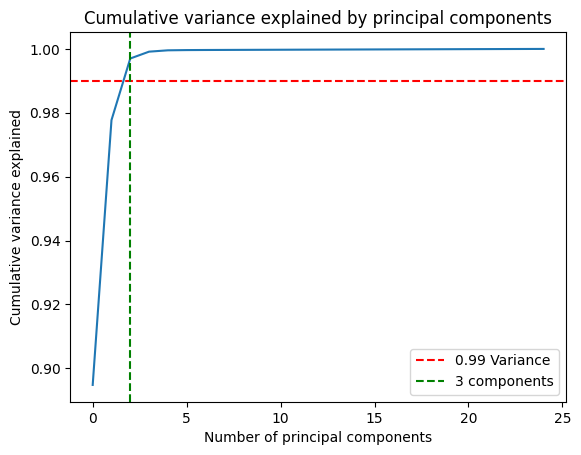

In [17]:
train_trajs = trajs['train_trajs'].sequence
train_trajs = train_trajs.reshape(-1, train_trajs.shape[-1])
# compute variance explained of each principal component
from sklearn.decomposition import PCA
pca = PCA(n_components=train_trajs.shape[1])
pca.fit(train_trajs)
variance_explained = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(variance_explained)

# Find dimension explaining at least 99% variance
thresh = 0.99
dim_thresh = np.argmax(cumulative_variance >= thresh) + 1

plt.plot(cumulative_variance)
plt.axhline(thresh, color='red', linestyle='--', label=f'{thresh} Variance')
plt.axvline(dim_thresh-1, color='green', linestyle='--', label=f'{dim_thresh} components')
plt.xlabel('Number of principal components')
plt.ylabel('Cumulative variance explained')
plt.title('Cumulative variance explained by principal components')
plt.legend()
plt.show()


## 6. Launch Sweep

Uses Hydra `--multirun` with the SLURM launcher. Checks W&B for already-completed
runs and only launches jobs for remaining parameter combinations.

> **Wait for all SLURM jobs to finish** before running the companion Analytics notebook.

In [18]:
def _get_sweep_param_from_run(run, key):
    """Extract a sweep parameter value from a W&B run config."""
    parts = key.split('.')
    val = run.config
    for p in parts:
        if not isinstance(val, dict) or p not in val:
            return None
        val = val[p]
    return val


def _combo_matches_run(combo, run):
    """Check if a parameter combination matches a finished W&B run."""
    for key, target_val in combo.items():
        run_val = _get_sweep_param_from_run(run, key)
        if run_val is None:
            return False
        if isinstance(target_val, bool):
            if bool(run_val) != target_val:
                return False
        elif isinstance(target_val, (int, float)):
            if abs(float(run_val) - float(target_val)) > 1e-10:
                return False
        else:
            if str(run_val) != str(target_val):
                return False
    return True


def _is_jac_ode_run(run):
    """Return True if this run has an encoder (i.e. is a JacobianODE run)."""
    return 'model' in run.config and 'encoder' in run.config.get('model', {})

In [19]:
# ----------------------------------------------------------------
# Check which parameter combinations already have completed runs
# ----------------------------------------------------------------
api = wandb.Api()
try:
    run_filters = {"group": WANDB_GROUP} if WANDB_GROUP else None
    existing_runs = api.runs(WANDB_PROJECT_PATH, filters=run_filters)
    msg = f"Found {len(existing_runs)} total runs in {WANDB_PROJECT_PATH}"
    if WANDB_GROUP:
        msg += f" (group={WANDB_GROUP})"
    print(msg)
except Exception as e:
    print(f"Could not query project (may not exist yet): {e}")
    existing_runs = []

finished_runs = [r for r in existing_runs if r.state == 'finished' and _is_jac_ode_run(r)]
already_done = []
remaining_combos = []
for combo in all_sweep_combos:
    if any(_combo_matches_run(combo, r) for r in finished_runs):
        already_done.append(combo)
        run_match = next(r for r in finished_runs if _combo_matches_run(combo, r))
        print(f"  Already done: {combo} (run_id={run_match.id})")
    else:
        remaining_combos.append(combo)

if already_done:
    print(f"\nSkipping {len(already_done)} already-completed combinations")
if remaining_combos:
    print(f"Need to run {len(remaining_combos)} combinations")
else:
    print("\nAll parameter combinations already have finished runs -- no sweep needed!")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/eisenaj/.netrc.


Found 0 total runs in JacobianODE/Lorenz_IND0_N25_D1_NormTrue_T3__coupling__JacobianODE (group=sweep_from_scratch_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5_stab)
Need to run 9 combinations


In [20]:
# ----------------------------------------------------------------
# Build the Hydra --multirun sweep command(s)
# ----------------------------------------------------------------
ENTRY_POINT = (
    "python -m JacobianODE.jacobians.run_jacobians"
    if MODE == "from_scratch"
    else "python -m JacobianODE.jacobians.run_pretrained_jacobians"
)

if remaining_combos:
    # Base overrides: exclude keys that are being swept
    _swept_keys = set(SWEEP_PARAMS.keys())
    def _is_swept(ov):
        for k in _swept_keys:
            if ov.strip().startswith(k + "="):
                return True
        return False
    fixed_overrides = [ov for ov in overrides if not _is_swept(ov)]

    n_remaining = len(remaining_combos)
    use_subset_sweep = n_remaining < n_sweep_combos

    if use_subset_sweep:
        # One command per remaining combo
        sweep_cmds = []
        for combo in remaining_combos:
            combo_overrides = [
                f"{key}={str(val).lower() if isinstance(val, bool) else val}"
                for key, val in combo.items()
            ]
            sweep_overrides = fixed_overrides + combo_overrides + [
                f"wandb_entity={WANDB_ENTITY}",
                f"wandb_project={WANDB_PROJECT}",
                "slurm=default",
            ]
            if WANDB_GROUP:
                sweep_overrides.append(f"wandb_group={WANDB_GROUP}")
            sweep_cmds.append(f"{ENTRY_POINT} --multirun " + " ".join(sweep_overrides))
    else:
        # Full grid sweep: comma-separated values
        sweep_param_overrides = []
        for key, vals in SWEEP_PARAMS.items():
            val_str = ",".join(str(v).lower() if isinstance(v, bool) else str(v) for v in vals)
            sweep_param_overrides.append(f"{key}={val_str}")
        sweep_overrides = fixed_overrides + sweep_param_overrides + [
            f"wandb_entity={WANDB_ENTITY}",
            f"wandb_project={WANDB_PROJECT}",
            "slurm=default",
        ]
        if WANDB_GROUP:
            sweep_overrides.append(f"wandb_group={WANDB_GROUP}")
        sweep_cmds = [f"{ENTRY_POINT} --multirun " + " ".join(sweep_overrides)]

    sweep_type = "subset (1 cmd per combo)" if use_subset_sweep else "grid"
    print(f"Sweep: {n_remaining} jobs ({sweep_type})")
    print(f"\nFirst command:\n{sweep_cmds[0][:200]}...")
else:
    sweep_cmds = []
    print("No sweep to launch -- all runs already completed.")

Sweep: 9 jobs (grid)

First command:
python -m JacobianODE.jacobians.run_jacobians --multirun model.params.hidden_dim=[256,1024,2048,2048] model.params.num_layers=4 model.params.activation=silu model.prediction_steps=30 data.postprocessi...


In [21]:
# ----------------------------------------------------------------
# Run one config locally (no SLURM) — exceptions show in notebook
# ----------------------------------------------------------------
# Set to True to run; uses all_sweep_combos[DIAG_COMBO_IX]
RUN_DIAG_LOCAL = False  # <-- Set True to diagnose
DIAG_COMBO_IX = 0

if RUN_DIAG_LOCAL:
    _swept_keys = set(SWEEP_PARAMS.keys())
    def _is_swept(ov):
        for k in _swept_keys:
            if ov.strip().startswith(k + "="):
                return True
        return False
    _fixed = [ov for ov in overrides if not _is_swept(ov)]
    _combo = all_sweep_combos[DIAG_COMBO_IX]
    _combo_ov = [f"{k}={str(v).lower() if isinstance(v, bool) else v}" for k, v in _combo.items()]
    _local_overrides = _fixed + _combo_ov + [
        f"wandb_entity={WANDB_ENTITY}",
        f"wandb_project={WANDB_PROJECT}",
        "slurm=none",  # No SLURM launcher — runs in-process (Hydra default)
    ]
    if WANDB_GROUP:
        _local_overrides.append(f"wandb_group={WANDB_GROUP}")
    _cmd = f"{ENTRY_POINT} " + " ".join(_local_overrides)
    print("Running locally (no SLURM). Any exception will appear below:\n")
    print(_cmd[:300] + "...\n")
    subprocess.run(_cmd, shell=True)
else:
    print("RUN_DIAG_LOCAL=False. Set to True and re-run to diagnose one config locally.")

RUN_DIAG_LOCAL=False. Set to True and re-run to diagnose one config locally.


In [22]:
print(f"WANDB_PROJECT = \"{WANDB_PROJECT}\"")
print(f"WANDB_GROUP = \"{WANDB_GROUP}\"")


WANDB_PROJECT = "Lorenz_IND0_N25_D1_NormTrue_T3__coupling__JacobianODE"
WANDB_GROUP = "sweep_from_scratch_coupling_lc_9vals__zp1.0__te0.0_enc_warmup_5_stab"


In [ ]:
# Launch the sweep (submits SLURM jobs)
if sweep_cmds:
    if len(sweep_cmds) > 1:
        print(f"Starting {len(sweep_cmds)} commands in parallel...")
    procs = [subprocess.Popen(cmd, shell=True) for cmd in sweep_cmds]
    for i, p in enumerate(procs):
        p.wait()
        if p.returncode != 0 and len(procs) > 1:
            print(f"Command {i + 1}/{len(procs)} exited with code {p.returncode}")
    print("Sweep complete.")
else:
    print("No sweep to launch -- all runs already completed.")

Sweep output dir : multirun/2026-03-24/14-08-09-285622
[2026-03-24 14:08:09,421][HYDRA] Submitit 'slurm' sweep output dir : multirun/2026-03-24/14-08-09-285622
[2026-03-24 14:08:09,423][HYDRA] 	#0 : model.params.hidden_dim=[256,1024,2048,2048] model.params.num_layers=4 model.params.activation=silu model.prediction_steps=30 data.postprocessing.obs_noise=0.01 data.postprocessing.normalize=True data.train_test_params.delay_embedding_params.observed_indices=[0] data.train_test_params.delay_embedding_params.n_delays=25 data.train_test_params.delay_embedding_params.delay_spacing=1 data.train_test_params.seq_length=45 data=dysts data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz data.trajectory_params.n_periods=12 data.trajectory_params.pts_per_period=100 data.trajectory_params.num_ics=32 training.batch_size=32 training.logger.save_dir=/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs training.lightning.optimizer_kwargs.lr=0.0001 training.lightning.optimizer_kwargs.weig

## Next Steps

Once all SLURM jobs have finished, use the companion
**Sweep Analytics (Latent JacobianODE)** notebook to:

1. Collect results from W&B
2. Apply physics-informed model selection (C1/C2/C3)
3. Load and diagnose the best model

Set the same `WANDB_PROJECT` and `WANDB_GROUP` in that notebook.